# Riesgo de crédito

## ¿Qué es el riesgo de crédito?

El riesgo de crédito es la forma más antigua de riesgo en los mercados financieros, puede ser definida como la expectativa de que una suma de dinero prestada no sea pagada dentro del tiempo límite estipulado.

Indica la posibilidad de que un cliente de crédito no cumpla a tiempo las disposiciones del contrato y deje de pagar el capital y/o los intereses (Duffy & Germani, 2013).

El concepto, cuando se aplica a empresas comerciales no financieras, se refiere a la posibilidad de pérdida causada por el impago por parte de un cliente de las obligaciones que ha asumido.

El riesgo de crédito se refiere aquí únicamente al riesgo de impago. El otro aspecto principal del riesgo de crédito es el riesgo de diferencial o el riesgo de un cambio en el valor debido a un cambio en el diferencial cubierto por el riesgo de mercado.

Para los bancos, el riesgo de crédito suele ser el mayor riesgo en forma de una serie de préstamos a particulares y pequeñas empresas. Otra fuente importante de riesgo de crédito para muchos bancos es el riesgo de contraparte en las operaciones con derivados.

## Métodos tradicionales de medición

### Método de expertos

-  Conocer al sujeto del crédito (Character): Solvencia moral, reputación y disposición para cumplir con los compromisos con terceros.

-  Capacidad de pago (Capacity): El flujo de efectivo generalmente es un buen reflejo de la capacidad de pago.

-  Capital de una firma: Permite conocer la contribución de los accionistas de la empresa. No son deseables altos niveles de apalancamiento.

-  Colateral (Collateral): Garantías para el crédito.

-  Condiciones cíclicas (Cycle Economic Conditions): Condiciones externas que pueden afectar el nivel de riesgo de crédito.

### Modelos para calcular probabilidad de incumplimiento

-  Modelos econométricos.

-  Modelos KMV y Moody’s

-  Redes neuronales artificiales (ANN)

### Modelos basados en Merton (El valor de los activos es menor al valor de los pasivos)

### Agencias de calificación de crédito

## Default en prestamos

El área de la modelización del riesgo de crédito se refiere al caso de impago de un préstamo.

Cuando un banco concede un préstamo a un tomador de crédito, que puede ser un particular o una empresa, el banco suele transferir la totalidad del importe del préstamo al prestatario.

![Prestamo](https://raw.githubusercontent.com/salas317/Data/main/GRF/Prestamo_1.png)

Y este suceso ocurrirá una y otra vez, con el banco concediendo préstamos a particulares y empresas cada vez más.

![Prestamo_2](https://raw.githubusercontent.com/salas317/Data/main/GRF/Prestamo_2.png)

Por supuesto, existe cierto riesgo de que el prestatario no pueda reembolsar íntegramente el préstamo. Esto supone una pérdida para el banco.

![Prestamo_3](https://raw.githubusercontent.com/salas317/Data/main/GRF/Prestamo_3.png)

## Perdida esperada por no pago

La perdida esperada para el banco esta compuesta por tres elementos:

1.  La probabilidad de impago (PD) es la probabilidad de que el prestatario no reembolse íntegramente el préstamo.

2.   La exposición en caso de impago (EAD) es el valor esperado del préstamo en el momento del impago. También puede considerarse como el importe del préstamo que aún debe reembolsarse en el momento del impago.

3.  La pérdida en caso de impago (LGD) es el importe de la pérdida en caso de impago, expresado como porcentaje de la EAD.

Multiplicando estos tres elementos se obtiene la fórmula de la pérdida esperada.

$$
EL = PD \times EAD \times LGD
$$

## Información que emplean los bancos

Los bancos conservan información sobre el comportamiento de impago de clientes anteriores, que puede utilizarse para predecir el impago de nuevos clientes. A grandes rasgos, esta información puede clasificarse en dos tipos:

1.  **Información sobre la solicitud:** Ejemplos de información sobre la solicitud son los ingresos, el estado civil, etc.

2.  **Información sobre el comportamiento:** hace un seguimiento del comportamiento pasado de los clientes, por ejemplo, el saldo de la cuenta corriente y el historial de pagos atrasados.

Observemos las primeras líneas de nuestra base de datos llamada `loan_data`

En esta base de datos se tiene información de préstamos pasados

Cada línea representa a un cliente en conjunto de su información, en conjunto con el estado de su préstamo, el cual toma el valor de 1 si el cliente ha entrado en default y 0 si el cliente ha cumplido con los pagos.

El `estado del préstamo` se considera como la variable de respuesta. 0 cuando el cliente es cumplido, 1 cuando se ha entrado en default.

Las variables explicativas son:

-  El valor del préstamo

-  La tasa de interés

-  El grado

-  Tiempo como empleado

-  Tipo de vivienda en la que reside

-  Ingreso anual

-  Edad

La calificación es la puntuación del cliente en el bureau, donde A indica la clase más alta de solvencia y G la más baja. Esta puntuación del buró refleja el historial crediticio del individuo y es la única variable de comportamiento del conjunto de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from matplotlib import colors
from pandas.api.types import CategoricalDtype

Importemos la base de datos

In [2]:
loan_data = pd.read_csv(filepath_or_buffer = "https://raw.githubusercontent.com/salas317/Data/main/GRF/loan_data_ch1.csv", index_col = 0)
loan_data

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age
1,0,5000,10.65,B,10.0,RENT,24000.0,33
2,0,2400,NaN,C,25.0,RENT,12252.0,31
3,0,10000,13.49,C,13.0,RENT,49200.0,24
4,0,5000,NaN,A,3.0,RENT,36000.0,39
5,0,3000,NaN,E,9.0,RENT,48000.0,24
...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27
29089,0,8500,10.28,C,3.0,RENT,18000.0,25
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23


In [3]:
loan_data.dtypes

loan_status         int64
loan_amnt           int64
int_rate          float64
grade              object
emp_length        float64
home_ownership     object
annual_inc        float64
age                 int64
dtype: object

Podemos ver que los campos `grade` y `home_ownership`, que deberían ser factores o categóricos, están como texto. Vamos a corregir esto. 

-   Vamos a crear el tipo de vivienda como una variable categórica no ordenada.
-   La variable grado como una ordenada.

In [4]:
loan_data["home_ownership"] = loan_data["home_ownership"].astype("category") # Convertimos la variable en categórica no ordenada

cat_type = CategoricalDtype(categories = list("GFEDCBA"), ordered=True, )
loan_data["grade"] = loan_data["grade"].astype(cat_type)

loan_data.dtypes

loan_status          int64
loan_amnt            int64
int_rate           float64
grade             category
emp_length         float64
home_ownership    category
annual_inc         float64
age                  int64
dtype: object

In [5]:
loan_data["grade"]

1        B
2        C
3        C
4        A
5        E
        ..
29088    A
29089    C
29090    A
29091    A
29092    E
Name: grade, Length: 29092, dtype: category
Categories (7, object): ['G' < 'F' < 'E' < 'D' < 'C' < 'B' < 'A']

## Tablas de conteo y tablas cruzadas

Para obtener una visión general de la estructura de datos de las variables categóricas, puede utilizar las funciones `value_counts` y `crosstab` de `pandas`.

Aplicando esta función a la variable home_ownership, se obtiene una tabla con cada una de las categorías de esta variable, con el número de casos y proporciones.

In [6]:
loan_data["home_ownership"].value_counts(normalize =  False, sort = True, dropna = False)

home_ownership
RENT        14692
MORTGAGE    12002
OWN          2301
OTHER          97
Name: count, dtype: int64

In [7]:
loan_data["home_ownership"].value_counts(normalize =  True, sort = True, dropna = False).round(decimals = 3)

home_ownership
RENT        0.505
MORTGAGE    0.413
OWN         0.079
OTHER       0.003
Name: proportion, dtype: float64

Para la calificación de los clientes se tiene:

In [8]:
loan_data["grade"].value_counts(normalize =  False, sort = True, dropna = False)

grade
A    9649
B    9329
C    5748
D    3231
E     868
F     211
G      56
Name: count, dtype: int64

In [9]:
loan_data["grade"].value_counts(normalize =  True, sort = True, dropna = False).round(decimals = 3)

grade
A    0.332
B    0.321
C    0.198
D    0.111
E    0.030
F    0.007
G    0.002
Name: proportion, dtype: float64

Ahora vamos a crear una tabla cruzada del tipo de vivienda con el estado del préstamo, calculando la proporción por fila.

In [10]:
pd.crosstab(index = loan_data["home_ownership"], columns = loan_data["loan_status"], margins = True)

loan_status,0,1,All
home_ownership,,,
MORTGAGE,10821,1181,12002
OTHER,80,17,97
OWN,2049,252,2301
RENT,12915,1777,14692
All,25865,3227,29092


In [11]:
pd.crosstab(index = loan_data["home_ownership"], columns = loan_data["loan_status"], normalize = "index").round(decimals = 3)

loan_status,0,1
home_ownership,,
MORTGAGE,0.902,0.098
OTHER,0.825,0.175
OWN,0.890,0.110
RENT,0.879,0.121


Ahora bien, ¿qué dice el resultado de la tabla? Parece ser que el porcentaje de personas que incumple sus pagos y que su tipo de vivienda es de la categoría OTHER es más alto en relación con los demás grupos.

## Análisis gráfico básico

Construyamos un histograma de la tasa de interés

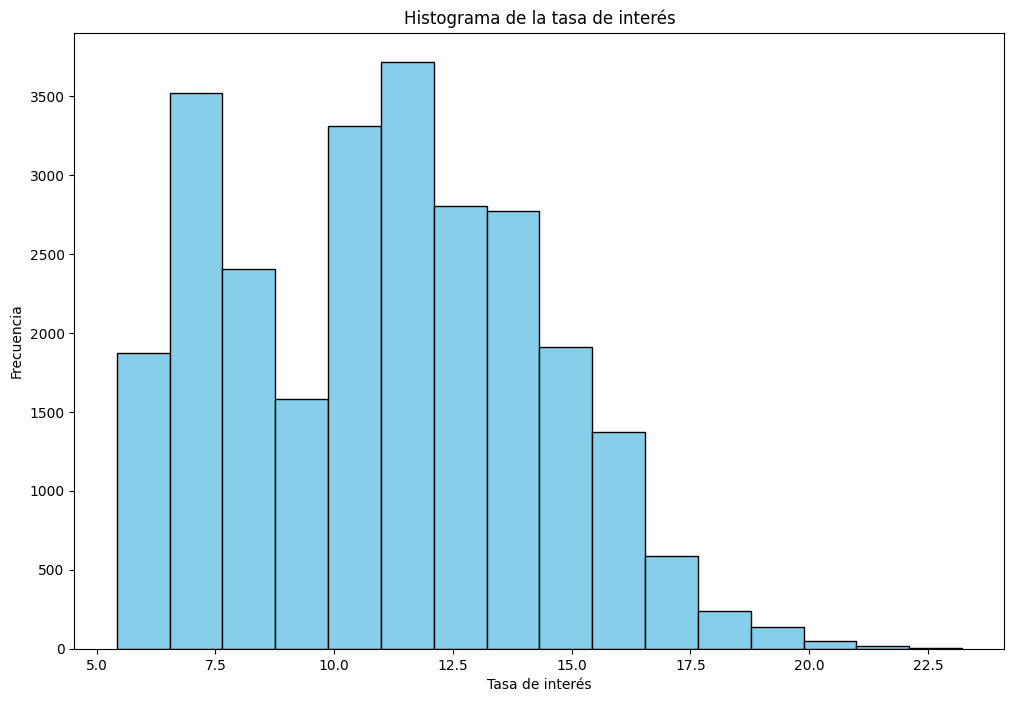

In [12]:
plt.figure(figsize=(12, 8))
plt.hist(x = loan_data["int_rate"], bins = "sturges", color = "skyblue", edgecolor = "black")
plt.title("Histograma de la tasa de interés")
plt.xlabel("Tasa de interés")
plt.ylabel("Frecuencia")
plt.show()

Ahora, observemos que pasa con los ingresos anuales.

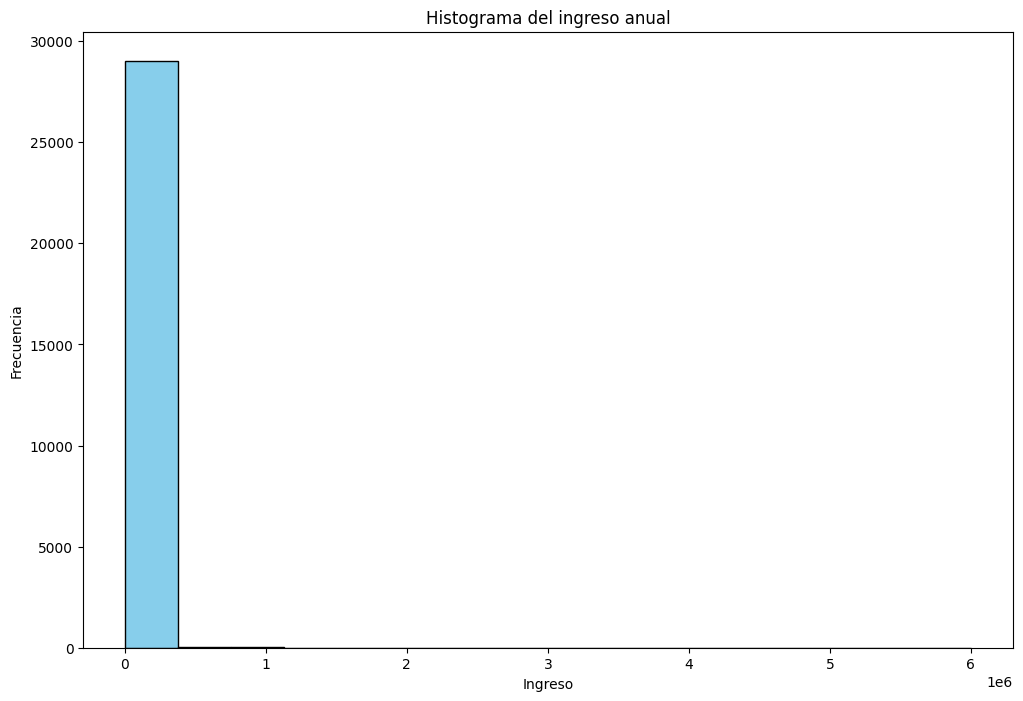

In [13]:
plt.figure(figsize=(12, 8))
plt.hist(x = loan_data["annual_inc"], bins = "sturges", color = "skyblue", edgecolor = "black")
plt.title("Histograma del ingreso anual")
plt.xlabel("Ingreso")
plt.ylabel("Frecuencia")
plt.show()

Algo extraño ocurre, pareciera que todas las personas en la base de datos tienen ingresos nulos o muy bajos.

Si observamos el objeto breaks en el histograma podemos observar los puntos de corte y hacernos una idea de la estructura del gráfico.

In [14]:
plt.figure(figsize=(12, 8))
n, bins, patches = plt.hist(x = loan_data["annual_inc"], bins = "sturges", color = "skyblue", edgecolor = "black")
plt.close() # Para no generar el gráfico, solo queremos los datos del histograma

print("Cortes del histograma:")
for i in range(len(bins) - 1):
    print(f"Bin {i+1}: {bins[i]:.2f} a {bins[i+1]:.2f} — Frecuencia: {n[i]:.0f}")

Cortes del histograma:
Bin 1: 4000.00 a 378750.00 — Frecuencia: 29013
Bin 2: 378750.00 a 753500.00 — Frecuencia: 57
Bin 3: 753500.00 a 1128250.00 — Frecuencia: 13
Bin 4: 1128250.00 a 1503000.00 — Frecuencia: 5
Bin 5: 1503000.00 a 1877750.00 — Frecuencia: 1
Bin 6: 1877750.00 a 2252500.00 — Frecuencia: 2
Bin 7: 2252500.00 a 2627250.00 — Frecuencia: 0
Bin 8: 2627250.00 a 3002000.00 — Frecuencia: 0
Bin 9: 3002000.00 a 3376750.00 — Frecuencia: 0
Bin 10: 3376750.00 a 3751500.00 — Frecuencia: 0
Bin 11: 3751500.00 a 4126250.00 — Frecuencia: 0
Bin 12: 4126250.00 a 4501000.00 — Frecuencia: 0
Bin 13: 4501000.00 a 4875750.00 — Frecuencia: 0
Bin 14: 4875750.00 a 5250500.00 — Frecuencia: 0
Bin 15: 5250500.00 a 5625250.00 — Frecuencia: 0
Bin 16: 5625250.00 a 6000000.00 — Frecuencia: 1


## Puntos atípicos

Vamos a observar un diagrama de dispersión para ver que puede estar pasando.

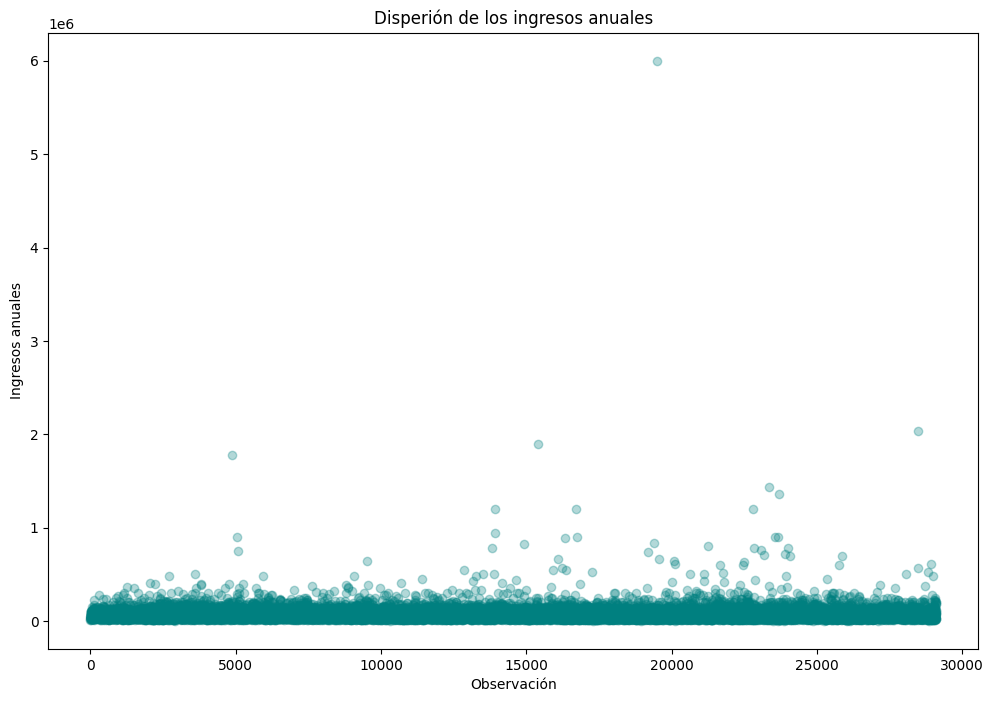

In [15]:
plt.figure(figsize=(12, 8))
plt.scatter(x = range(len(loan_data["annual_inc"])), y = loan_data["annual_inc"], color  = "teal", alpha = 0.3)
plt.title("Disperión de los ingresos anuales")
plt.xlabel("Observación")
plt.ylabel("Ingresos anuales")
plt.show()

Se observa que hay una observación con un salario cercano a los 6 millones de dólares, cuando los demás casos no superan los 2 millones de dólares anuales. Podemos considerar esta observación como un dato atípico.

## Datos atípicos

Un dato atípico es un dato que esta distante de una manera anormal de los demás valores. Pero ¿Cómo detectar un dato atípico? Exploremos dos posibles caminos:

### Juicio de expertos:

A partir de nuestro conocimiento de los datos podemos definir un criterio para determinar un dato como atípico.

In [16]:
loan_data_expert = loan_data[loan_data["annual_inc"] <= 3000000]
loan_data_expert

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age
1,0,5000,10.65,B,10.0,RENT,24000.0,33
2,0,2400,NaN,C,25.0,RENT,12252.0,31
3,0,10000,13.49,C,13.0,RENT,49200.0,24
4,0,5000,NaN,A,3.0,RENT,36000.0,39
5,0,3000,NaN,E,9.0,RENT,48000.0,24
...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27
29089,0,8500,10.28,C,3.0,RENT,18000.0,25
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23


Miremos que tantos datos se descartaron con el uso del método de los expertos.

In [17]:
loan_data.shape

(29092, 8)

In [18]:
loan_data_expert.shape

(29091, 8)

### Criterio de intervalo intercuartílico

Otra forma es utilizar el rango intercuartilico para definir, a partir de los mismos datos, cuales observaciones son atípicas. Esto lo hacemos considerando como atipico cualquier valor que se encuentre por fuera del siguiente rango:

$$
LI = Q1 - 1.5 \times RIC \\
LS = Q3 + 1.5 \times RIC
$$

In [19]:
q1 = loan_data["annual_inc"].quantile(0.25)
q3 = loan_data["annual_inc"].quantile(0.75)

iqr = q3 - q1

li = q1 - 1.5 * iqr
ls = q3 + 1.5 * iqr

print(f"LI: {li}, LS: {ls}")

LI: -20000.0, LS: 140000.0


Vamos a descartar el limite inferior, no tenemos ingresos negativos.

In [20]:
loan_data_ROT = loan_data[loan_data["annual_inc"] <= ls]
loan_data_ROT

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age
1,0,5000,10.65,B,10.0,RENT,24000.0,33
2,0,2400,NaN,C,25.0,RENT,12252.0,31
3,0,10000,13.49,C,13.0,RENT,49200.0,24
4,0,5000,NaN,A,3.0,RENT,36000.0,39
5,0,3000,NaN,E,9.0,RENT,48000.0,24
...,...,...,...,...,...,...,...,...
29087,0,5000,8.70,B,5.0,MORTGAGE,75000.0,35
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27
29089,0,8500,10.28,C,3.0,RENT,18000.0,25
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27


In [21]:
loan_data_ROT.shape

(27710, 8)

Observemos que pasa con los datos después de eliminar los datos atípicos

Se puede ver que son más informativos que el grafico original, sin embargo, es más claro el grafico que resulta de usar el intervalo intercuartílico.

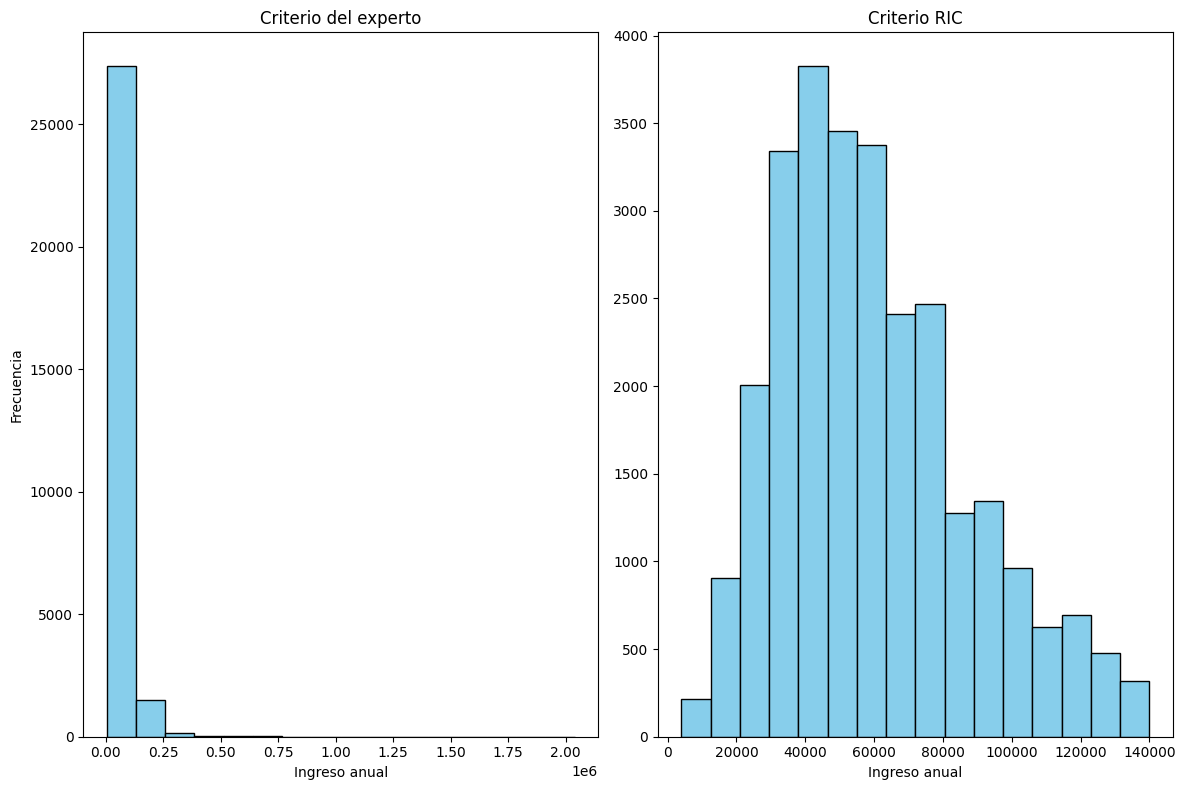

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize=(12, 8))

# Histograma 1
ax1.hist(loan_data_expert["annual_inc"], bins = "sturges", color = "skyblue", edgecolor = "black")
ax1.set_title("Criterio del experto")
ax1.set_xlabel("Ingreso anual")
ax1.set_ylabel("Frecuencia")

# Histograma 2
ax2.hist(loan_data_ROT["annual_inc"], bins = "sturges", color = "skyblue", edgecolor = "black")
ax2.set_title("Criterio RIC")
ax2.set_xlabel("Ingreso anual")

# Ajustar espacio entre los subgráficos
plt.tight_layout()
plt.show()

Se puede notar que se eliminaron más observaciones empleando el criterio del intervalo. Ahora bien, si no se desean eliminar las observaciones, lo cual es totalmente valido. Puede ser útil, eliminarlas temporalmente para hacer los gráficos.

## Gráfico bivariado

Un grafico bivariado nos permite observar cómo se comporta una variable en relación con otra. Esta es una forma de mostrar posibles puntos atípicos en dos dimensiones.

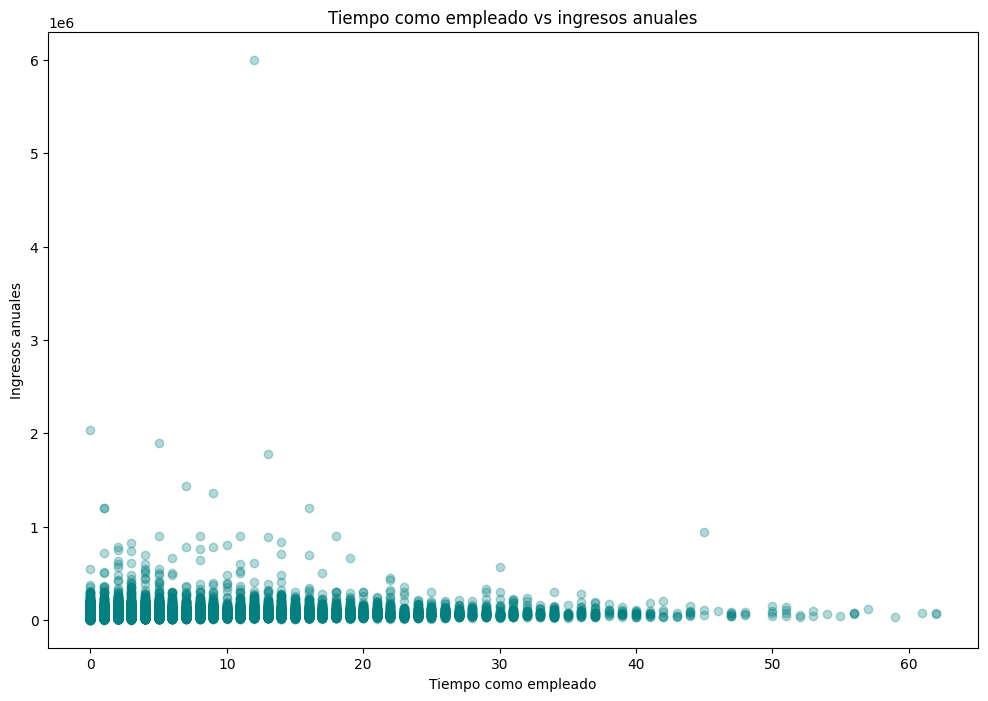

In [23]:
# Grafico de ingresos vs tiempo como empleado

plt.figure(figsize=(12, 8))
plt.scatter(x = loan_data["emp_length"], y = loan_data["annual_inc"], color  = "teal", alpha = 0.3)
plt.title("Tiempo como empleado vs ingresos anuales")
plt.xlabel("Tiempo como empleado")
plt.ylabel("Ingresos anuales")
plt.show()

## Datos omitidos

En muchas bases de datos, esta no es la excepción, existen datos omitidos (NA’s)

Lo primero que nos interesa, es saber cuantos datos omitidos existen. Una forma mas sencilla de verlo es con `isna().sum()`

In [24]:
loan_data.isna().sum()

loan_status          0
loan_amnt            0
int_rate          2776
grade                0
emp_length         809
home_ownership       0
annual_inc           0
age                  0
dtype: int64

La pregunta es ¿Que podemos hacer con los datos omitidos?

### Eliminar los registros con datos atípicos

Identificamos y eliminamos las observaciones en las cuales el tiempo de empleado tiene valores omitidos.

In [25]:
loan_data_no_NA = loan_data.dropna(subset = ["emp_length"])
loan_data_no_NA

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age
1,0,5000,10.65,B,10.0,RENT,24000.0,33
2,0,2400,NaN,C,25.0,RENT,12252.0,31
3,0,10000,13.49,C,13.0,RENT,49200.0,24
4,0,5000,NaN,A,3.0,RENT,36000.0,39
5,0,3000,NaN,E,9.0,RENT,48000.0,24
...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27
29089,0,8500,10.28,C,3.0,RENT,18000.0,25
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23


In [26]:
loan_data_no_NA.isna().sum()

loan_status          0
loan_amnt            0
int_rate          2712
grade                0
emp_length           0
home_ownership       0
annual_inc           0
age                  0
dtype: int64

### Reemplazarlos

Se puede reemplazar el valor omitido con la media o la mediana de las demás observaciones.

In [27]:
loan_data_replace = loan_data.copy()
loan_data_replace["emp_length"] = loan_data_replace["emp_length"].fillna(value = loan_data_replace["emp_length"].median(skipna = True))
loan_data_replace

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age
1,0,5000,10.65,B,10.0,RENT,24000.0,33
2,0,2400,NaN,C,25.0,RENT,12252.0,31
3,0,10000,13.49,C,13.0,RENT,49200.0,24
4,0,5000,NaN,A,3.0,RENT,36000.0,39
5,0,3000,NaN,E,9.0,RENT,48000.0,24
...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27
29089,0,8500,10.28,C,3.0,RENT,18000.0,25
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23


In [28]:
loan_data_replace.isna().sum()

loan_status          0
loan_amnt            0
int_rate          2776
grade                0
emp_length           0
home_ownership       0
annual_inc           0
age                  0
dtype: int64

### Conservarlos

En ocasiones no es buena idea eliminar ni modificar los datos omitidos. Sin embargo, esto puede ocasionar que algunos métodos no los consideren por defecto.

Una forma de resolver este nuevo problema es crear una nueva variable que sea categórica a partir de los valores de la variable de interés.

Para nuestro caso del tiempo como empleado vamos a crear una nueva variable `emp_cat`. La cual parte el tiempo en rangos de 15 años. Las categorias son:

-  0-15
-  15-30
-  30-45
-  45+
-  missing

In [29]:
# Creamos los cortes
cortes = [-1, 15, 30, 45, 1000]

# Creamos las etiquetas
etiquetas = ["0-15", "15-30", "30-45", "45+"]

# Creamos la nueva variable
loan_data["emp_cat"] = pd.cut(x = loan_data["emp_length"], bins = cortes, labels = etiquetas, right = True)

# Asignamos el valor missing a los casos de valores omitidos
loan_data["emp_cat"] = loan_data["emp_cat"].cat.add_categories("missing").fillna(value = "missing")
loan_data

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age,emp_cat
1,0,5000,10.65,B,10.0,RENT,24000.0,33,0-15
2,0,2400,NaN,C,25.0,RENT,12252.0,31,15-30
3,0,10000,13.49,C,13.0,RENT,49200.0,24,0-15
4,0,5000,NaN,A,3.0,RENT,36000.0,39,0-15
5,0,3000,NaN,E,9.0,RENT,48000.0,24,0-15
...,...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27,0-15
29089,0,8500,10.28,C,3.0,RENT,18000.0,25,0-15
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27,0-15
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23,0-15


In [30]:
loan_data.isna().sum()

loan_status          0
loan_amnt            0
int_rate          2776
grade                0
emp_length         809
home_ownership       0
annual_inc           0
age                  0
emp_cat              0
dtype: int64

Creemos un gráfico de la nueva variable que hemos creado

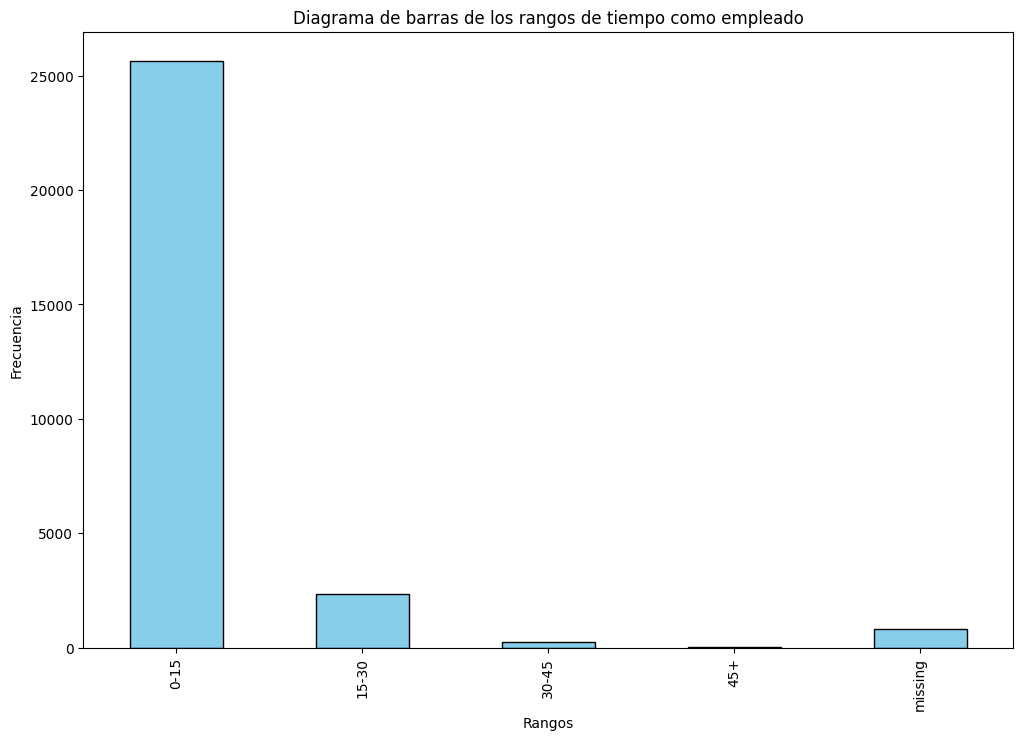

In [31]:
plt.figure(figsize=(12, 8))
loan_data["emp_cat"].value_counts(sort = False).plot(kind = "bar", color = "skyblue", edgecolor = "black")
plt.title("Diagrama de barras de los rangos de tiempo como empleado")
plt.xlabel("Rangos")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de las observaciones están concentradas en el primer rango. Puede ser razonable observar diferentes cortes, pero con frecuencia similares.

In [32]:
loan_data["emp_length"].quantile(q = [0, 0.25, 0.5, 0.75, 1])

0.00     0.0
0.25     2.0
0.50     4.0
0.75     8.0
1.00    62.0
Name: emp_length, dtype: float64

Usemos estos cortes para tener mejor distribuidos los datos.

In [33]:
# Creamos los cortes
cortes = [-1, 2, 4, 8, 1000]

# Creamos las etiquetas
etiquetas = ["0-2", "2-4", "4-8", "8+"]

# Creamos la nueva variable
loan_data["emp_cat"] = pd.cut(x = loan_data["emp_length"], bins = cortes, labels = etiquetas, right = True)

# Asignamos el valor missing a los casos de valores omitidos
loan_data["emp_cat"] = loan_data["emp_cat"].cat.add_categories("missing").fillna(value = "missing")
loan_data

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age,emp_cat
1,0,5000,10.65,B,10.0,RENT,24000.0,33,8+
2,0,2400,NaN,C,25.0,RENT,12252.0,31,8+
3,0,10000,13.49,C,13.0,RENT,49200.0,24,8+
4,0,5000,NaN,A,3.0,RENT,36000.0,39,2-4
5,0,3000,NaN,E,9.0,RENT,48000.0,24,8+
...,...,...,...,...,...,...,...,...,...
29088,0,2500,8.07,A,4.0,MORTGAGE,110000.0,27,2-4
29089,0,8500,10.28,C,3.0,RENT,18000.0,25,2-4
29090,0,5000,8.07,A,0.0,MORTGAGE,100000.0,27,0-2
29091,0,5000,7.43,A,0.0,MORTGAGE,200000.0,23,0-2


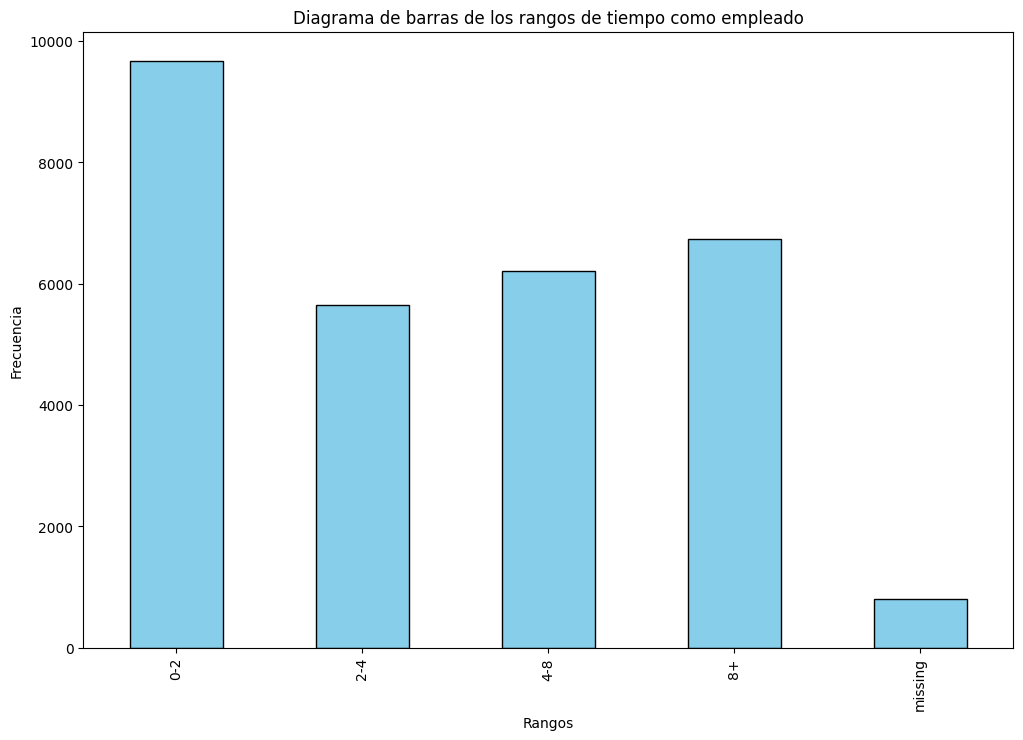

In [34]:
plt.figure(figsize=(12, 8))
loan_data["emp_cat"].value_counts(sort = False).plot(kind = "bar", color = "skyblue", edgecolor = "black")
plt.title("Diagrama de barras de los rangos de tiempo como empleado")
plt.xlabel("Rangos")
plt.ylabel("Frecuencia")
plt.show()

Que hacer si la variable es categorica:

|Acción|Variable continua|Variable discreta|
|:-----|:----------------|:----------------|
|Borrar|Borrar registro|Borrar registro|
|Reemplazar|Reemplazar usando mediana o media|Reemplazar usando la moda|
|Conservar|Conservar usando una variable categórica|Crear categoría NA|

## División de los datos y matrices de confusión

Un modelo para calcular estimar el impago de nuevos clientes se puede construir usando toda la base de datos de los clientes antiguos. Pero, esta practica generalmente lleva a modelos muy optimistas que pueden no funcionar muy bien con datos externos a la base de datos.

![Data whole](<https://raw.githubusercontent.com/salas317/Data/main/GRF/data whole.png>)

Una alternativa consiste en partir los datos en dos partes, la primera parte la llamaremos datos de entrenamiento, la cual emplearemos para construir el modelo. La segunda parte de los datos será llamada datos de prueba y se empleará para probar la efectividad del modelo.

![Data split](<https://raw.githubusercontent.com/salas317/Data/main/GRF/data split.png>)

## Evaluación del modelo

Evaluar el modelo es compara los valores reales de la variable loan_status en nuestra base de datos con los valores que prediga el modelo que vamos a construir.

Si se trabaja con una cantidad grande de datos a evaluar, un método popular para organizar los resultados es la matriz de confusión. Hagamos un ejemplo con 14 observaciones.

In [35]:
loan_status = [1] + [0]*5 + [1]*2 + [0]*3 + [1] + [0]*2
model_prediction = [1] + [0]*4 + [1, 0, 1] + [0]*3 + [1, 0, 1]

test_set = pd.DataFrame({
    'loan_status': loan_status,
    'model_prediction': model_prediction
})

test_set

,loan_status,model_prediction
0,1,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,1
6,1,0
7,1,1
8,0,0
9,0,0


In [36]:
pd.crosstab(index = test_set["loan_status"], columns = test_set["model_prediction"], )

model_prediction,0,1
loan_status,,
0,8,2
1,1,3


A partir de la matriz de confusión se pueden calcular tres medidas para observar el desempeño del modelo.

La **precisión** de la clasificación es el porcentaje de casos clasificados correctamente.

La **sensibilidad** es el porcentaje de clientes malos clasificados correctamente.

La **especificidad** es el porcentaje de buenos clientes que se clasifican correctamente.

![Matriz](<https://raw.githubusercontent.com/salas317/Data/main/GRF/matriz.png>)

Las medidas se calculan como:

$$
Precisión = \frac{TP+TN}{TP+FP+TN+FN} 
$$

$$
Sensibilidad = \frac{TP}{TP+FN}
$$

$$
Especificidad = \frac{TN}{TN+FP}
$$

Las medidas para nuestro ejemplo son las siguientes:

$$
Precisión = \frac{8+3}{8+2+1+3} = \frac{11}{14} = 78.57\%
$$

$$
Sensibilidad = \frac{3}{3+1} = \frac{3}{4} = 75\%
$$

$$
Especificidad = \frac{8}{8+2} = \frac{8}{10} = 80\%
$$

In [37]:
tn, fp, fn, tp = confusion_matrix(test_set["loan_status"], test_set["model_prediction"]).ravel()


In [38]:
precision = (tp + tn)/(tp+fp+tn+fn)
print(f"La precición es de: {precision:.2%}")

La precición es de: 78.57%


In [39]:
sensibilidad = tp/(tp+fn)
print(f"La sensibilidad es de: {sensibilidad:.2%}")

La sensibilidad es de: 75.00%


In [40]:
especificidad = tn/(tn+fp)
print(f"La especificidad es de: {especificidad:.2%}")

La especificidad es de: 80.00%


## Como crear la base de datos de pruebas

Lo primero que se debe de hacer es definir una semilla al momento de separar los datos. Esta función permite que los datos aleatorios usados para crear la base de datos de muestra puedan ser replicados.

Usando la función `train_test_split` se seleccionan las observaciones que harán parte de la base de datos de entrenamiento y de pruebas.

El primer argumento es la base de datos que se va a emplear.

El segundo elemento es el tamaño de la muestra de prueba, se recomienda usar 1/3. De manera que la base de datos de entrenamiento contendrá dos terceras partes de los datos.

El tercer elemento es el random_state, este define la semilla, que permite replicar los resultados.

Vamos a hacer una prueba con la base de datos de `loan_data`

In [41]:
train_set, test_set = train_test_split(loan_data, test_size = 1/3, random_state = 42)
print(train_set.shape)
print(test_set.shape)

(19394, 9)
(9698, 9)


In [42]:
train_set.head()

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age,emp_cat
12846,0,15850,11.11,B,7.0,MORTGAGE,60000.0,24,4-8
3796,0,5000,7.90,A,5.0,MORTGAGE,24000.0,22,4-8
1220,0,5500,9.91,B,6.0,MORTGAGE,59000.0,33,4-8
4528,0,6000,7.90,A,3.0,RENT,25200.0,27,2-4
863,0,10000,15.96,C,2.0,RENT,47500.0,31,0-2


In [43]:
test_set.head()

,loan_status,loan_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,age,emp_cat
21442,0,12000,10.99,B,8.0,RENT,54050.0,31,4-8
3223,0,1000,8.90,A,5.0,RENT,85000.0,52,4-8
2241,0,2300,7.90,A,25.0,MORTGAGE,109200.0,26,8+
3173,1,1500,16.29,D,0.0,OWN,48000.0,22,0-2
6482,0,25000,16.49,D,7.0,RENT,72000.0,24,4-8
